In [1]:
import pandas as pd
import numpy as np
import re
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm

In [ ]:
# 1. Configuration (Verify these paths!)
DRIVE_PATH = '/content/drive/MyDrive/Project'
GROUND_TRUTH_PATH = f'{DRIVE_PATH}/data/filtered_experimental_set.csv'
MODEL_NAME = 'all-MiniLM-L6-v2' # Standard for semantic similarity
PERSONAS = ['naive', 'formal', 'expert']

In [ ]:
def calculate_completeness(text):
    """
    Measures 'Completeness' by checking if the LLM identified 
    the three pillars of a vulnerability: Source, Sink, and Trigger.
    """
    if not isinstance(text, str): return 0
    
    attributes = {
        'sink': r'(buffer|memory|pointer|array|index|sink|heap|stack|variable)',
        'source': r'(input|parameter|user|recv|read|arg|scanf|gets|file)',
        'trigger': r'(overflow|bounds|null|check|validation|trigger|format|leak|corruption)'
    }
    
    score = 0
    text_lower = text.lower()
    for attr, pattern in attributes.items():
        # Using search ensures we only count the category once if any keyword exists
        if re.search(pattern, text_lower):
            score += 1
    return score

In [3]:
# The Targeted Slicer
def clean_explanation(text):
    """
    Isolates the technical reasoning core while stripping persona-driven 
    introductory filler and structural artifacts.
    """
    if not isinstance(text, str) or len(text) < 10: 
        return "N/A"
    
    # Remove code blocks
    text = re.sub(r'```.*?```', '', text, flags=re.DOTALL)
    
    # Attempt to isolate the ANALYSIS section specifically
    analysis_match = re.search(r'ANALYSIS:\s*(.*?)(?=IMPACT:|STOP:|VULNERABILITY:|$)', 
                               text, re.IGNORECASE | re.DOTALL)
    
    if analysis_match:
        content = analysis_match.group(1).strip()
    else:
        # Fallback: if headers are missing, just remove the VULNERABILITY name line
        content = re.sub(r'^.*?VULNERABILITY:.*?\n', '', text, flags=re.IGNORECASE).strip()
    
    # Normalize whitespace and limit to 100 words to ensure we only compare 
    # the technical core, not the 'Formal' filler.
    words = content.split()
    return " ".join(words[:100])

In [4]:
# 3. Load SBERT Model
print("--- Loading SBERT Model ---")
device = "cuda" if torch.cuda.is_available() else "cpu"
sbert_model = SentenceTransformer(MODEL_NAME).to(device)

--- Loading SBERT Model ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
# 4. Main Consolidated Analysis
def run_evaluation():
    print("--- Starting Consolidated RQ2 Evaluation ---")
    truth_df = pd.read_csv(GROUND_TRUTH_PATH)
    truth_col = 'truth_description'
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sbert_model = SentenceTransformer('all-MiniLM-L6-v2').to(device)

    all_results = []
    
    for persona in PERSONAS:
        res_path = f'{DRIVE_PATH}/results/rq2_{persona}_results.csv'
        if not os.path.exists(res_path):
            print(f"Skipping {persona}: File not found.")
            continue
            
        print(f"Processing Persona: {persona.upper()}")
        df = pd.read_csv(res_path)
        
        # Merge with Ground Truth
        merged = pd.merge(df, truth_df[['index', truth_col]], on='index')
        
        # Apply Metrics
        merged['cleaned_res'] = merged['generated_explanation'].apply(clean_explanation)
        merged['word_count'] = merged['generated_explanation'].apply(lambda x: len(str(x).split()))
        merged['completeness_score'] = merged['generated_explanation'].apply(calculate_completeness)
        
        # SBERT Encoding
        gen_emb = sbert_model.encode(merged['cleaned_res'].tolist(), convert_to_tensor=True)
        truth_emb = sbert_model.encode(merged[truth_col].tolist(), convert_to_tensor=True)
        
        # Calculate row-wise similarity
        merged['sbert_sim'] = torch.diag(util.cos_sim(truth_emb, gen_emb)).cpu().numpy()
        
        # Information Density: Accuracy vs log-Verbosity
        merged['info_density'] = merged['sbert_sim'] / np.log1p(merged['word_count'])
        
        merged['persona'] = persona
        all_results.append(merged)

    final_df = pd.concat(all_results)
    
    # Save for paper visualization
    final_df.to_csv(f'{DRIVE_PATH}/results/rq2_consolidated_analysis.csv', index=False)
    return final_df


--- Analyzing Persona: NAIVE ---
Encoding 64 samples...

--- Analyzing Persona: FORMAL ---
Encoding 64 samples...

--- Analyzing Persona: EXPERT ---
Encoding 64 samples...


/tmp/ipykernel_13151/885985089.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='persona', y='sbert_similarity', data=full_df, order=PERSONAS, palette='Set2')



--- RQ2 FINAL RESULTS TABLE ---
Persona  Mean Similarity  Similarity StdDev  Avg Raw Word Count  Information Density
 expert         0.331592           0.145922          265.328125             0.001250
 formal         0.330940           0.166645          290.015625             0.001141
  naive         0.323050           0.155058          262.718750             0.001230


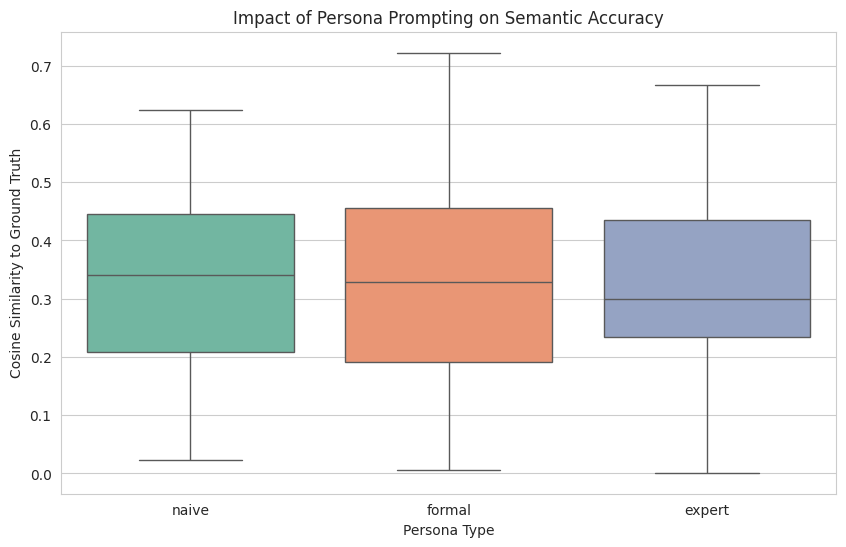

In [6]:
# 5. Execute
stats_df, full_df = run_evaluation()

In [ ]:
# 4. Visualization: The "Sycophancy Trap" Scatter Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=full_df, x='word_count', y='sbert_sim', hue='persona', alpha=0.6)
plt.title('The Persona Bias Trap: Verbosity vs. Semantic Accuracy')
plt.xlabel('Word Count (Verbosity)')
plt.ylabel('SBERT Similarity (Accuracy)')
plt.savefig(f'{DRIVE_PATH}/results/rq2_sycophancy_scatter.png')

In [ ]:
# 5. Completeness Table
print("\n--- CWE Completeness & Precision by Persona ---")
pivot = full_df.groupby('persona').agg({
    'sbert_sim': 'mean',
    'word_count': 'mean',
    'completeness_score': 'mean',
    'density': 'mean'
}).rename(columns={'completeness_score': 'Avg Security Attributes Identified'})
print(pivot.to_string())

In [ ]:
# 6. Side-by-Side Qualitative Export
# Pick a specific index to show the contrast
sample_idx = full_df['index'].iloc[0]
print(f"\n--- Side-by-Side Qualitative Comparison (Sample {sample_idx}) ---")
for p in PERSONAS:
    sample = full_df[(full_df['index'] == sample_idx) & (full_df['persona'] == p)]
    if not sample.empty:
        print(f"[{p.upper()}]: {sample.iloc[0]['generated_explanation'][:180]}...")